In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
import PIL
from PIL import Image
import os
import numpy as np
import pandas as pd
import pickle
import tarfile
from tqdm import tqdm_notebook as tqdm
#tqdm().pandas()
import tensorflow
#from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pydicom
import cv2

In [36]:
data_dir = "/home/gulfairus/.database/lung_cancer/data/raw"

In [37]:
train_df = pd.read_csv(os.path.join(data_dir, "miccai2023_nih-cxr-lt_labels_train.csv"))
val_df = pd.read_csv(os.path.join(data_dir, "miccai2023_nih-cxr-lt_labels_val.csv"))
test_df = pd.read_csv(os.path.join(data_dir, "miccai2023_nih-cxr-lt_labels_test.csv"))

In [38]:
def check_for_leakage(df1, df2, patient_col):

    df1_patients_unique = set(df1[patient_col])
    df2_patients_unique = set(df2[patient_col])

    patients_in_both_groups = list(df1_patients_unique.intersection(df2_patients_unique))

    if len(patients_in_both_groups) == 0:
        leakage = False
    else:
        leakage = True

    return leakage

In [39]:
check_for_leakage(train_df, val_df, 'subj_id')

False

In [40]:
check_for_leakage(test_df, val_df, 'subj_id')

False

In [41]:
check_for_leakage(train_df, test_df, 'subj_id')

False

In [42]:
train_df.head()

,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Pleural Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding,subj_id
0,00000001_000.png,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,00000001_001.png,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,00000001_002.png,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,00000002_000.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,2
4,00000004_000.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4


In [43]:
id = train_df['id'].apply(lambda x: x.split('.')[0] + '.dcm')
train_df['id'] = id

In [44]:
train_df.head()

,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Pleural Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding,subj_id
0,00000001_000.dcm,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,00000001_001.dcm,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,00000001_002.dcm,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,00000002_000.dcm,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,2
4,00000004_000.dcm,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4


In [45]:
train_id = list(train_df["id"].values)
#train_id

In [46]:
labels = train_df.drop(columns=['id', 'subj_id'])
labels = labels.apply(lambda x: x.to_list(), axis=1)
labels.to_list()

[[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [47]:
import tensorflow as tf

# Create a simple dataset
data = tf.constant([1, 2, 3, 4, 5])
dataset = tf.data.Dataset.from_tensor_slices(data).batch(2).prefetch(tf.data.AUTOTUNE)

# Correct way to get elements
iterator = iter(dataset)
print(next(iterator))

tf.Tensor([1 2], shape=(2,), dtype=int32)


In [48]:
iterator = iter(dataset)
print(next(iterator))

tf.Tensor([1 2], shape=(2,), dtype=int32)


In [49]:
class_counts = train_df.sum().drop(['id','subj_id'])

In [50]:
for column in class_counts.keys():
    print(f"The class {column} has {train_df[column].sum()} samples")

The class Atelectasis has 7587 samples
The class Cardiomegaly has 1590 samples
The class Consolidation has 2626 samples
The class Edema has 1283 samples
The class Effusion has 7919 samples
The class Emphysema has 1327 samples
The class Fibrosis has 1138 samples
The class Hernia has 130 samples
The class Infiltration has 12739 samples
The class Mass has 3689 samples
The class Nodule has 4359 samples
The class Pleural Thickening has 1998 samples
The class Pneumonia has 806 samples
The class Pneumothorax has 2432 samples
The class Pneumoperitoneum has 214 samples
The class Pneumomediastinum has 88 samples
The class Subcutaneous Emphysema has 957 samples
The class Tortuous Aorta has 598 samples
The class Calcification of the Aorta has 368 samples
The class No Finding has 44625 samples


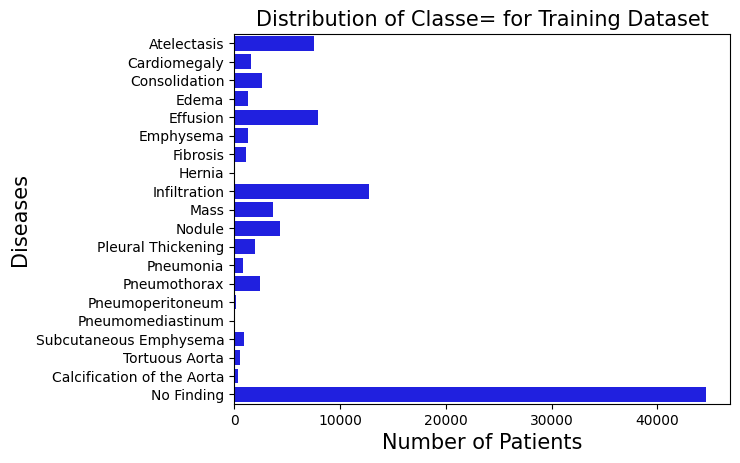

In [51]:
sns.barplot(x=class_counts.values, y=class_counts.index, color='b')
plt.title('Distribution of Classe= for Training Dataset', fontsize=15)
plt.xlabel('Number of Patients', fontsize=15)
plt.ylabel('Diseases', fontsize=15)
plt.show()

## Weighted Loss Function

In [52]:
''' # Step 2: Compute TF-IDF weights for labels
label_counts = np.sum(Y, axis=0)
TF = label_counts / len(Y)
IDF = np.log((1 + len(Y)) / (1 + label_counts)) + 1  # Smoothing
TF_IDF = TF * IDF
weights = 1.0 / TF_IDF  # Invert to give higher weights to rarer labels
weights = weights / np.max(weights)  # Normalize to [0, 1]
weights
'''

' # Step 2: Compute TF-IDF weights for labels\nlabel_counts = np.sum(Y, axis=0)\nTF = label_counts / len(Y)\nIDF = np.log((1 + len(Y)) / (1 + label_counts)) + 1  # Smoothing\nTF_IDF = TF * IDF\nweights = 1.0 / TF_IDF  # Invert to give higher weights to rarer labels\nweights = weights / np.max(weights)  # Normalize to [0, 1]\nweights\n'

In [53]:
labels = train_df.drop(columns=['id', 'subj_id'])
labels = labels.apply(lambda x: x.to_list(), axis=1)
labels = labels.to_list()

In [54]:
label_counts = np.sum(labels, axis=0)
label_counts

array([ 7587,  1590,  2626,  1283,  7919,  1327,  1138,   130, 12739,
        3689,  4359,  1998,   806,  2432,   214,    88,   957,   598,
         368, 44625])

In [55]:
TF_pos = label_counts / len(labels)
TF_pos

array([0.09664229, 0.02025323, 0.03344967, 0.0163427 , 0.10087127,
       0.01690317, 0.01449571, 0.00165592, 0.16226785, 0.04699004,
       0.05552442, 0.02545028, 0.01026673, 0.03097852, 0.00272591,
       0.00112093, 0.01219015, 0.00761725, 0.00468754, 0.56842789])

In [56]:
TF_neg = 1 - TF_pos
TF_neg

array([0.90335771, 0.97974677, 0.96655033, 0.9836573 , 0.89912873,
       0.98309683, 0.98550429, 0.99834408, 0.83773215, 0.95300996,
       0.94447558, 0.97454972, 0.98973327, 0.96902148, 0.99727409,
       0.99887907, 0.98780985, 0.99238275, 0.99531246, 0.43157211])

In [57]:
columns = class_counts.keys()
columns

Index(['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
       'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule',
       'Pleural Thickening', 'Pneumonia', 'Pneumothorax', 'Pneumoperitoneum',
       'Pneumomediastinum', 'Subcutaneous Emphysema', 'Tortuous Aorta',
       'Calcification of the Aorta', 'No Finding'],
      dtype='object')

/tmp/ipykernel_26638/2233832999.py:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  data = data.append([{"Class": columns[l], "Label": "Negative", "Value": v} for l,v in enumerate(TF_neg)], ignore_index=True)


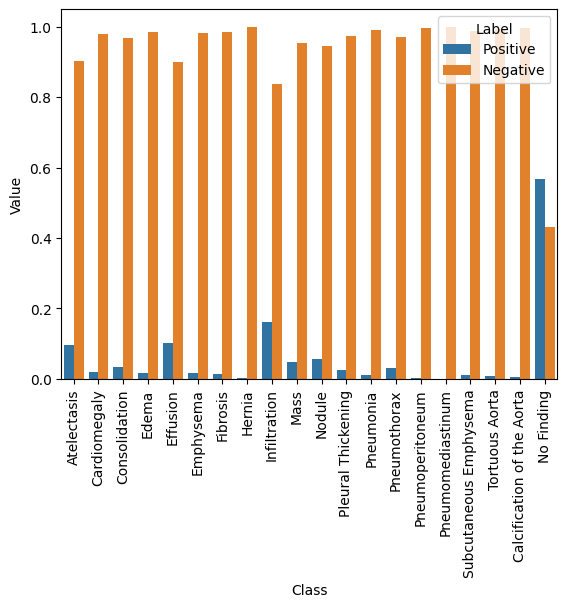

In [58]:
data = pd.DataFrame({"Class": columns, "Label": "Positive", "Value": TF_pos})
data = data.append([{"Class": columns[l], "Label": "Negative", "Value": v} for l,v in enumerate(TF_neg)], ignore_index=True)
plt.xticks(rotation=90)
f = sns.barplot(x="Class", y="Value", hue="Label" ,data=data)

In [59]:
pos_weights = TF_neg
neg_weights = TF_pos
pos_contribution = TF_pos * pos_weights
neg_contribution = TF_neg * neg_weights

In [60]:
pos_contribution

array([0.08730256, 0.01984304, 0.03233079, 0.01607562, 0.09069626,
       0.01661745, 0.01428558, 0.00165318, 0.135937  , 0.04478198,
       0.05244146, 0.02480257, 0.01016133, 0.03001885, 0.00271848,
       0.00111968, 0.01204155, 0.00755923, 0.00466557, 0.24531762])

In [61]:
neg_contribution

array([0.08730256, 0.01984304, 0.03233079, 0.01607562, 0.09069626,
       0.01661745, 0.01428558, 0.00165318, 0.135937  , 0.04478198,
       0.05244146, 0.02480257, 0.01016133, 0.03001885, 0.00271848,
       0.00111968, 0.01204155, 0.00755923, 0.00466557, 0.24531762])

/tmp/ipykernel_26638/1631297143.py:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  data = data.append([{"Class": columns[l], "Label": "Negative", "Value": v}


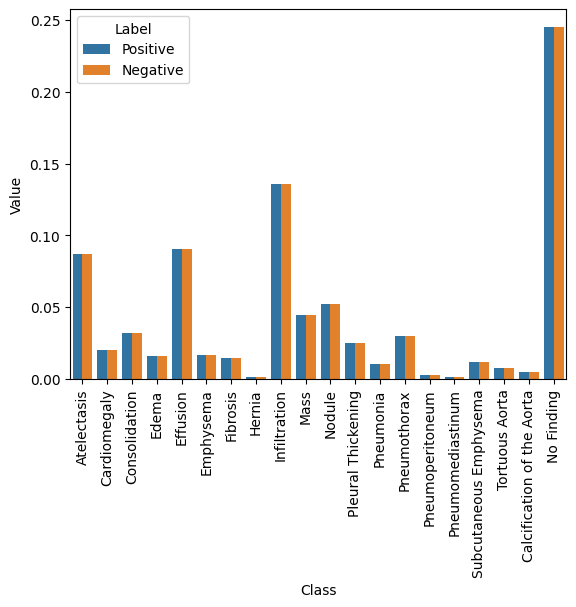

In [62]:
data = pd.DataFrame({"Class": columns, "Label": "Positive", "Value": pos_contribution})
data = data.append([{"Class": columns[l], "Label": "Negative", "Value": v}
                        for l,v in enumerate(neg_contribution)], ignore_index=True)
plt.xticks(rotation=90)
sns.barplot(x="Class", y="Value", hue="Label" ,data=data);

In [68]:
IDF = tf.keras.backend.log((1 + len(labels)) / (1 + label_counts)) + 1  # Smoothing
IDF = tf.cast(IDF, tf.float32)
IDF

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([3.3366199, 4.898825 , 4.397345 , 5.113208 , 3.2937965, 5.0795135,
       5.233037 , 7.3957458, 2.8184412, 4.0575614, 3.8907158, 4.670541 ,
       5.5776196, 4.474063 , 6.9003053, 7.7823067, 5.4060955, 5.8756814,
       6.3601465, 1.5648712], dtype=float32)>

In [69]:
label_counts

array([ 7587,  1590,  2626,  1283,  7919,  1327,  1138,   130, 12739,
        3689,  4359,  1998,   806,  2432,   214,    88,   957,   598,
         368, 44625])

In [70]:
TF_IDF_pos = TF_pos * IDF
weights_pos = 1.0 / TF_IDF_pos  # Invert to give higher weights to rarer labels
weights_pos = weights_pos / np.max(weights_pos)  # Normalize to [0, 1]
weights_pos

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0.02705293, 0.08792289, 0.05930698, 0.1043929 , 0.02625572,
       0.101601  , 0.11499923, 0.71230453, 0.01907422, 0.04575276,
       0.04038078, 0.07338857, 0.15233761, 0.06293981, 0.46377674,
       1.        , 0.13237177, 0.19490887, 0.2926012 , 0.00980696],
      dtype=float32)>

In [71]:
TF_IDF_neg = TF_neg * IDF
weights_neg = 1.0 / TF_IDF_neg  # Invert to give higher weights to rarer labels
weights_neg = weights_neg / np.max(weights_neg)  # Normalize to [0, 1]
weights_neg

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0.22406061, 0.1407104 , 0.15889744, 0.13427487, 0.2280412 ,
       0.13524261, 0.13095427, 0.09146813, 0.2860341 , 0.17465034,
       0.18378569, 0.14837502, 0.122339  , 0.15577453, 0.09814069,
       0.08687818, 0.12646633, 0.11582292, 0.1066855 , 1.        ],
      dtype=float32)>

In [67]:
with open('/home/gulfairus/.database/lung_cancer/data/processed/loss_weights.pkl', 'wb') as f:
    pickle.dump(weights, f)


with open('/home/gulfairus/.database/lung_cancer/data/processed/loss_weights.pkl', 'rb') as f:
    loss_weights = pickle.load(f)

print(f"Original list: {weights}")
print(f"Loaded list: {loss_weights}")

NameError: name 'weights' is not defined

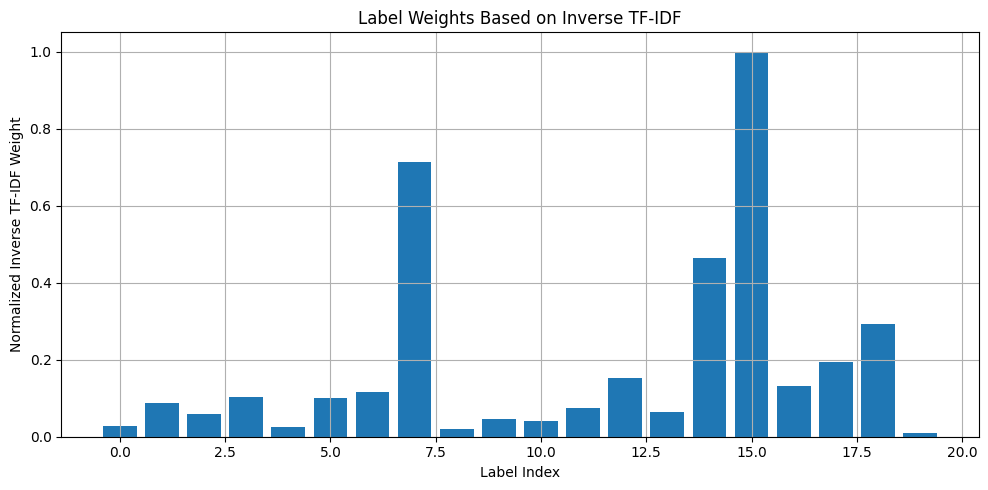

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(range(len(weights)), weights)
plt.xlabel('Label Index')
plt.ylabel('Normalized Inverse TF-IDF Weight')
plt.title('Label Weights Based on Inverse TF-IDF')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
dicom_dir = "/mnt/c/Users/User/Downloads/dicom/dicom"

Display Random Images


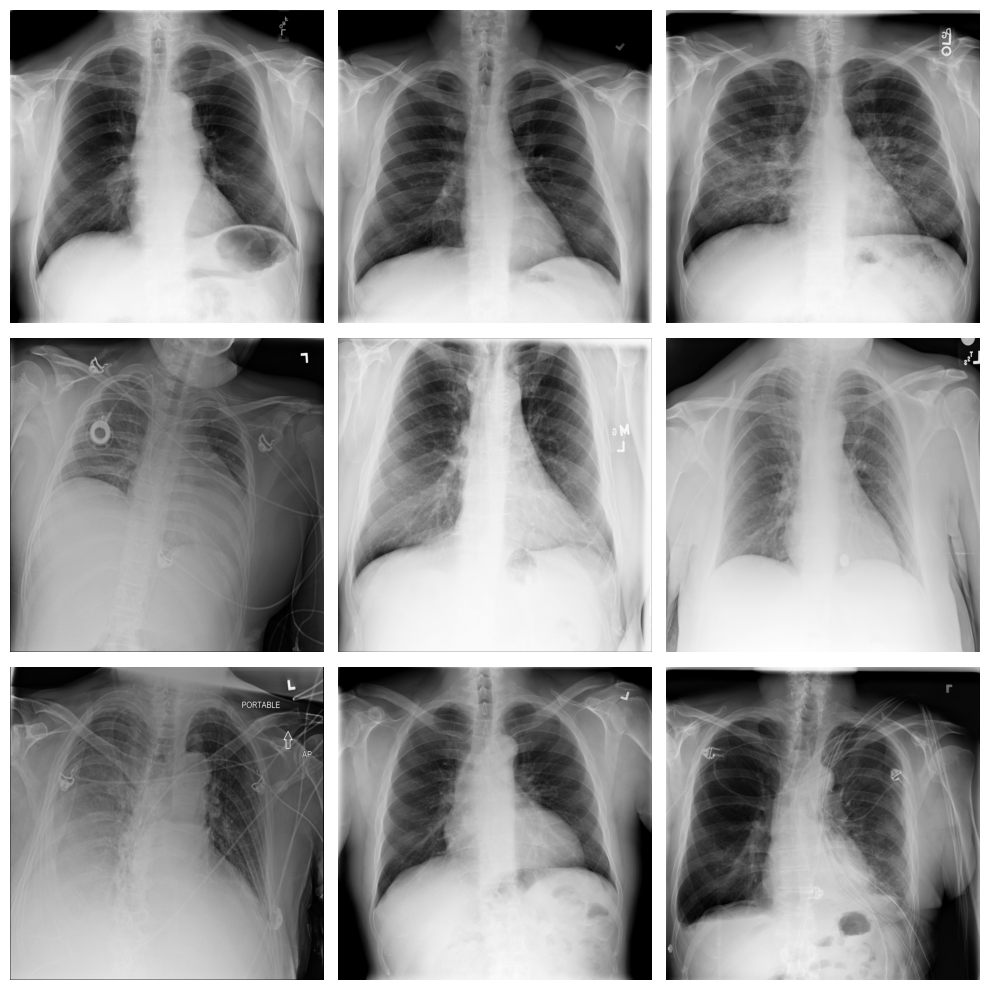

In [ ]:
# Extract numpy values from Image column in data frame
images = train_df['id'].values

# Extract 9 random images from it
random_images = [np.random.choice(images) for i in range(9)]

# Location of the image dir
img_dir = dicom_dir

print('Display Random Images')

# Adjust the size of your images
plt.figure(figsize=(10,10))

# Iterate and plot random images
for i in range(9):
    plt.subplot(3, 3, i + 1)
    im = random_images[i].split('.')[0]
    im = im + '.dcm'
    img = pydicom.dcmread(os.path.join(img_dir, im))
    img = img.pixel_array
    plt.imshow(img, cmap='gray')
    plt.axis('off')

# Adjust subplot parameters to give specified padding
plt.tight_layout()

In [ ]:
train_df[train_df['subj_id']==1]

,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Pleural Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding,subj_id
0,00000001_000.dcm,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,00000001_001.dcm,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,00000001_002.dcm,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


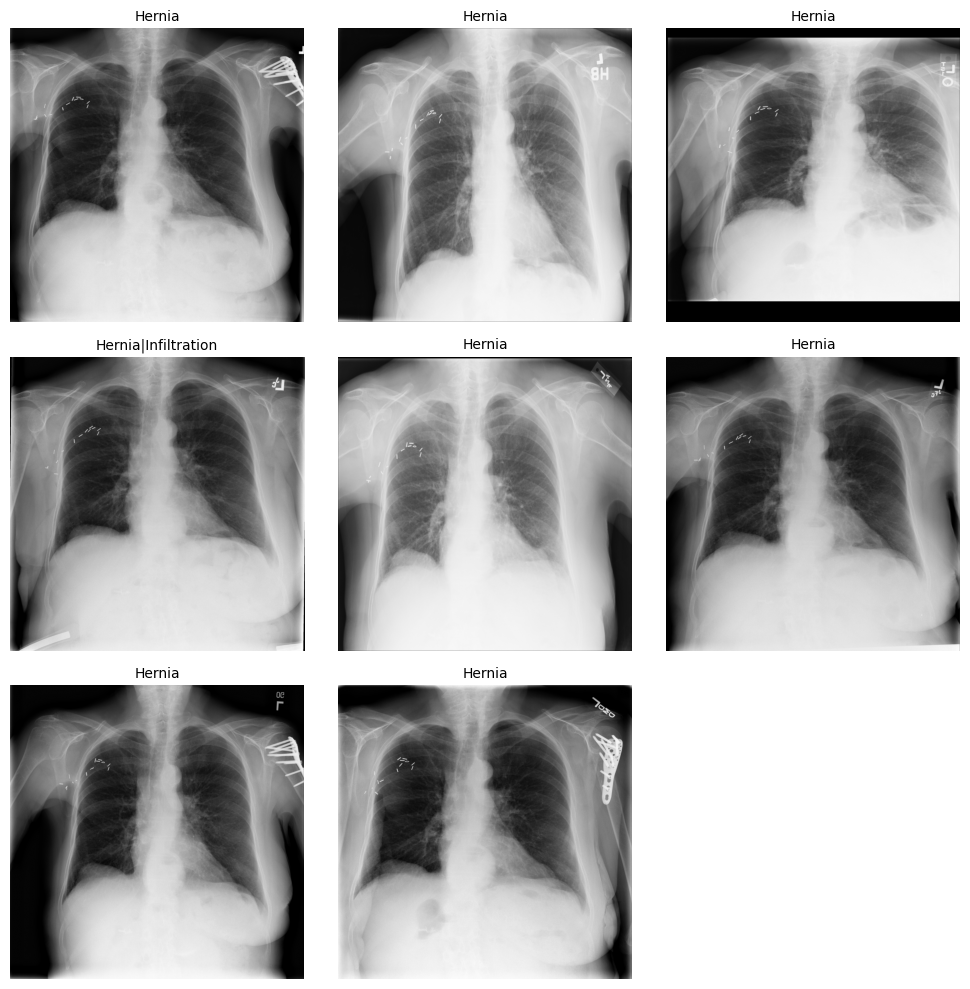

In [ ]:
plt.figure(figsize=(10,10))
#dicom_files = ["00000001_000.dcm", "00000001_001.dcm", "00000001_002.dcm"]
dicom_files = ["00000003_000.dcm", "00000003_001.dcm", "00000003_002.dcm", "00000003_003.dcm", "00000003_004.dcm", "00000003_005.dcm", "00000003_006.dcm", "00000003_007.dcm"]
# Iterate and plot random images
for i in range(8):
    sp = plt.subplot(3, 3, i + 1)
    img = pydicom.dcmread(os.path.join(img_dir, dicom_files[i]))
    img_arr = img.pixel_array
    plt.imshow(img_arr, cmap='gray')
    sp.set_title(img.StudyDescription, fontsize=10)
    plt.axis('off')

# Adjust subplot parameters to give specified padding
plt.tight_layout()

(1024, 1024, 3)


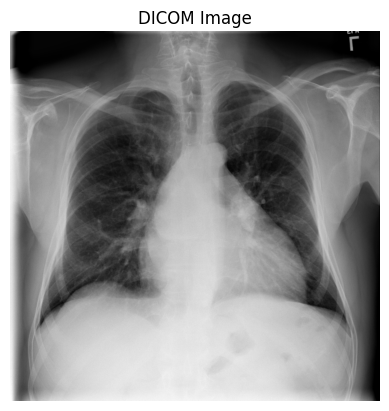

In [ ]:
# Load the DICOM file
dicom_file = pydicom.dcmread(os.path.join(dicom_dir, "00000001_000.dcm"))
#print(dicom_file.get_private_item)
# Extract the pixel data
image = dicom_file.pixel_array
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
# Show the image using matplotlib
plt.imshow(image, cmap=plt.cm.gray)
print(image.shape)
#plt.imshow(image)
plt.title("DICOM Image")
plt.axis("off")
plt.show()

In [ ]:
# Initialize PyRadiomics extractor
extractor = featureextractor.RadiomicsFeatureExtractor()

# Extract features
result = extractor.execute(image_sitk, mask_sitk)

# Print selected features
for key in sorted(result.keys()):
    if 'diagnostics' not in key:
        print(f"{key}: {result[key]}")

NameError: name 'featureextractor' is not defined

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def get_train_generator(df, image_dir, x_col, y_cols, shuffle=True, batch_size=8, seed=1, target_w=320, target_h=320):
    """
    Return generator for training set, normalizing using batch statistics.
    """
    print("Getting train generator...")

    # Validate column names
    if x_col not in df.columns or not all(col in df.columns for col in y_cols):
        raise ValueError("x_col or one of y_cols not found in dataframe")

    # Normalize images per sample
    image_generator = ImageDataGenerator(
        samplewise_center=True,
        samplewise_std_normalization=True
    )

    generator = image_generator.flow_from_dataframe(
        dataframe=df,
        directory=image_dir,
        x_col=x_col,
        y_col=y_cols,
        class_mode="raw",
        batch_size=batch_size,
        shuffle=shuffle,
        seed=seed,
        target_size=(target_h, target_w)  # Fix: height, width
    )

    return generator


In [ ]:
def load_dicom_image(path, image_size):
    ds = pydicom.dcmread(path)
    img = ds.pixel_array.astype(np.float32)
    img = cv2.resize(img, image_size)  # Resize to (H, W)
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    if len(img.shape) == 2:
        img = np.expand_dims(img, axis=-1)
    img = np.repeat(img, 3, axis=-1)  # Convert to 3 channels
    return img

In [ ]:
def compute_mean_std_train(df, image_dir, image_size=(320, 320)):
    pixels = []
    df = df[['id']]
    for i, row in df.iterrows():
        print(row)
        im = row['id'].split('.')[0]
        dic = im + '.dcm'
        img_path = f"{image_dir}/{dic}"
        img = load_dicom_image(img_path, image_size)
        #img = image.load_img(img_path, target_size=image_size)
        #img_array = image.img_to_array(img) / 255.0  # Scale to [0, 1]
        img_array = img / 255.0
        pixels.append(img_array)
    pixels = np.stack(pixels)
    print(pixels.shape)
    mean = np.mean(pixels, axis=(0, 1, 2))
    std = np.std(pixels, axis=(0, 1, 2))
    return mean, std

In [ ]:
train_mean, train_std = compute_mean_std_train(train_df, dicom_dir, image_size=(320, 320))

In [ ]:
# Extract numpy values from Image column in data frame
images = train_df['id'].values

# Extract 9 random images from it
random_images = [np.random.choice(images) for i in range(9)]

# Location of the image dir
img_dir = dicom_dir

print('Display Random Images')

# Adjust the size of your images
plt.figure(figsize=(10,10))

# Iterate and plot random images
for i in range(9):
    plt.subplot(3, 3, i + 1)
    im = random_images[i].split('.')[0]
    im = im + '.dcm'
    img = pydicom.dcmread(os.path.join(img_dir, im))
    img = img.pixel_array
    plt.imshow(img, cmap='gray')
    plt.axis('off')

# Adjust subplot parameters to give specified padding
plt.tight_layout()